# Unemployment Analysis with Python

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
plt.rcParams["figure.figsize"] = (10, 6)

# 2. LOAD DATASET

# Change this path to your CSV file name/location

In [4]:
df = pd.read_csv("Unemployment in India.csv")
print(df.head())



           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


# 3. BASIC DATASET INFORMATION

In [5]:

print("\n================ DATASET PREVIEW ================\n")
print(df.head())

print("\n================ LAST 5 ROWS ================\n")
print(df.tail())

print("\n================ DATASET SHAPE ================\n")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n================ COLUMN NAMES ================\n")
print(df.columns.tolist())

print("\n================ DATA TYPES ================\n")
print(df.dtypes)



================ DATASET PREVIEW ================

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  

================ LAST 5 ROWS

In [6]:
print("\n================ DATASET INFO ================\n")
df.info()


================ DATASET INFO ================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


# 4. CLEAN COLUMN NAMES

In [7]:
# Remove leading/trailing spaces
df.columns = df.columns.str.strip()

# Replace multiple spaces with a single space
df.columns = df.columns.str.replace(r"\s+", " ", regex=True)


In [8]:
print("\n================ CLEANED COLUMNS ================\n")
print(df.columns.tolist())


================ CLEANED COLUMNS ================

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


# 5. CHECK MISSING VALUES

In [9]:
print("\n================ MISSING VALUES ================\n")
print(df.isnull().sum())

print("\n================ MISSING VALUE PERCENTAGE ================\n")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)



================ MISSING VALUES ================

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

================ MISSING VALUE PERCENTAGE ================

Region                                     3.645833
Date                                       3.645833
Frequency                                  3.645833
Estimated Unemployment Rate (%)            3.645833
Estimated Employed                         3.645833
Estimated Labour Participation Rate (%)    3.645833
Area                                       3.645833
dtype: float64


# 6. CHECK DUPLICATE ROWS

In [10]:
print("\n================ DUPLICATE ROWS ================\n")

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)


# Remove duplicate rows
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

print("New shape:", df.shape)



================ DUPLICATE ROWS ================

Number of duplicate rows: 27
Duplicates removed.
New shape: (741, 7)


# 7. HANDLE MISSING VALUES

In [12]:

# Display rows containing missing values
print("\n================ ROWS WITH MISSING VALUES ================\n")
print(df[df.isnull().any(axis=1)].head())

# Fill numerical missing values with median
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Fill categorical missing values with mode
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])




================ ROWS WITH MISSING VALUES ================

    Region Date Frequency  Estimated Unemployment Rate (%)  \
359    NaN  NaN       NaN                              NaN   

     Estimated Employed  Estimated Labour Participation Rate (%) Area  
359                 NaN                                      NaN  NaN  


# 8. CONVERT DATE COLUMN

In [13]:
# Find a likely date column
date_column = None

possible_date_columns = [
    "Date",
    "date",
    "DATE",
    "Month",
    "month"
]

for col in possible_date_columns:
    if col in df.columns:
        date_column = col
        break

if date_column is not None:

    df[date_column] = pd.to_datetime(
        df[date_column],
        errors="coerce"
    )

    print("\nDate column converted successfully.")

else:
    print("\nNo date column found.")



Date column converted successfully.


C:\Users\sai\AppData\Local\Temp\ipykernel_18436\2996644164.py:19: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_column] = pd.to_datetime(


# 9. REMOVE EXTRA SPACES FROM TEXT COLUMNS

In [14]:
for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].astype(str).str.strip()

# 10. DESCRIPTIVE STATISTICS

In [15]:
print("\n================ DESCRIPTIVE STATISTICS ================\n")
print(df.describe())

print("\n================ ALL STATISTICS ================\n")
print(df.describe(include="all"))




================ DESCRIPTIVE STATISTICS ================

                                Date  Estimated Unemployment Rate (%)  \
count                            741                       741.000000   
mean   2019-12-12 18:12:08.744939264                        11.783306   
min              2019-05-31 00:00:00                         0.000000   
25%              2019-08-31 00:00:00                         4.660000   
50%              2019-11-30 00:00:00                         8.350000   
75%              2020-03-31 00:00:00                        15.880000   
max              2020-06-30 00:00:00                        76.740000   
std                              NaN                        10.714796   

       Estimated Employed  Estimated Labour Participation Rate (%)  
count        7.410000e+02                               741.000000  
mean         7.201140e+06                                42.628138  
min          4.942000e+04                                13.330000  
25%    

# 11. IDENTIFY UNEMPLOYMENT RATE COLUMN

In [16]:

unemployment_column = None

for column in df.columns:

    column_lower = column.lower()

    if (
        "unemployment rate" in column_lower
        or "unemployment" in column_lower
    ):
        unemployment_column = column
        break

print("\n================ UNEMPLOYMENT COLUMN ================\n")
print(unemployment_column)


================ UNEMPLOYMENT COLUMN ================

Estimated Unemployment Rate (%)


# 12. BASIC UNEMPLOYMENT STATISTICS

In [17]:
if unemployment_column is not None:

    print("\n================ UNEMPLOYMENT STATISTICS ================\n")

    print(
        "Average unemployment rate:",
        df[unemployment_column].mean()
    )

    print(
        "Minimum unemployment rate:",
        df[unemployment_column].min()
    )

    print(
        "Maximum unemployment rate:",
        df[unemployment_column].max()
    )

    print(
        "Median unemployment rate:",
        df[unemployment_column].median()
    )


================ UNEMPLOYMENT STATISTICS ================

Average unemployment rate: 11.783306342780028
Minimum unemployment rate: 0.0
Maximum unemployment rate: 76.74
Median unemployment rate: 8.35


# 13. HISTOGRAM OF UNEMPLOYMENT RATE

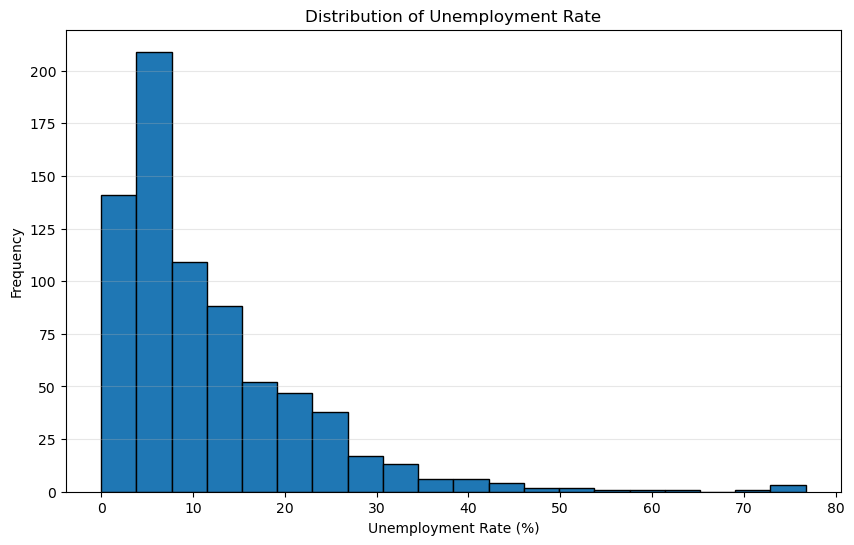

In [18]:
if unemployment_column is not None:

    plt.figure()

    plt.hist(
        df[unemployment_column],
        bins=20,
        edgecolor="black"
    )

    plt.title("Distribution of Unemployment Rate")
    plt.xlabel("Unemployment Rate (%)")
    plt.ylabel("Frequency")

    plt.grid(axis="y", alpha=0.3)

    plt.show()

# 14. BOXPLOT OF UNEMPLOYMENT RATE

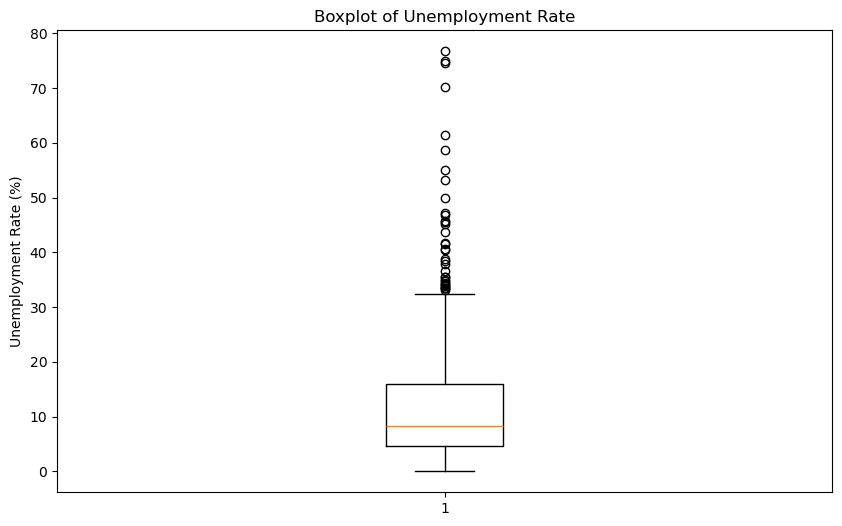

In [19]:

if unemployment_column is not None:

    plt.figure()

    plt.boxplot(
        df[unemployment_column].dropna()
    )

    plt.title("Boxplot of Unemployment Rate")
    plt.ylabel("Unemployment Rate (%)")

    plt.show()

# 15. FIND STATE/REGION COLUMN

In [20]:
region_column = None

possible_region_columns = [
    "Region",
    "region",
    "State",
    "state",
    "Area",
    "area"
]

for col in possible_region_columns:

    if col in df.columns:
        region_column = col
        break

print("\n================ REGION COLUMN ================\n")
print(region_column)


================ REGION COLUMN ================

Region


# 16. AVERAGE UNEMPLOYMENT RATE BY REGION

In [21]:
if region_column is not None and unemployment_column is not None:

    region_unemployment = (
        df.groupby(region_column)[unemployment_column]
        .mean()
        .sort_values(ascending=False)
    )

    print("\n================ AVERAGE UNEMPLOYMENT BY REGION ================\n")
    print(region_unemployment)


================ AVERAGE UNEMPLOYMENT BY REGION ================

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.507241
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


# 17. BAR CHART - TOP 10 REGIONS WITH HIGH UNEMPLOYMENT

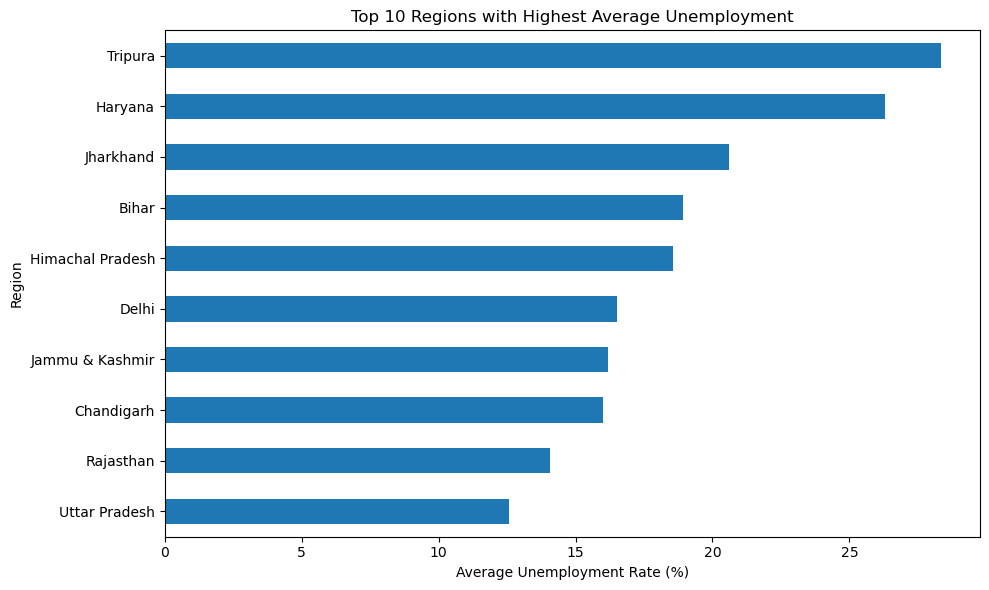

In [22]:
if region_column is not None and unemployment_column is not None:

    top_10 = region_unemployment.head(10)

    plt.figure()

    top_10.sort_values().plot(
        kind="barh"
    )

    plt.title("Top 10 Regions with Highest Average Unemployment")
    plt.xlabel("Average Unemployment Rate (%)")
    plt.ylabel("Region")

    plt.tight_layout()

    plt.show()


# 18. BAR CHART - LOWEST UNEMPLOYMENT REGIONS

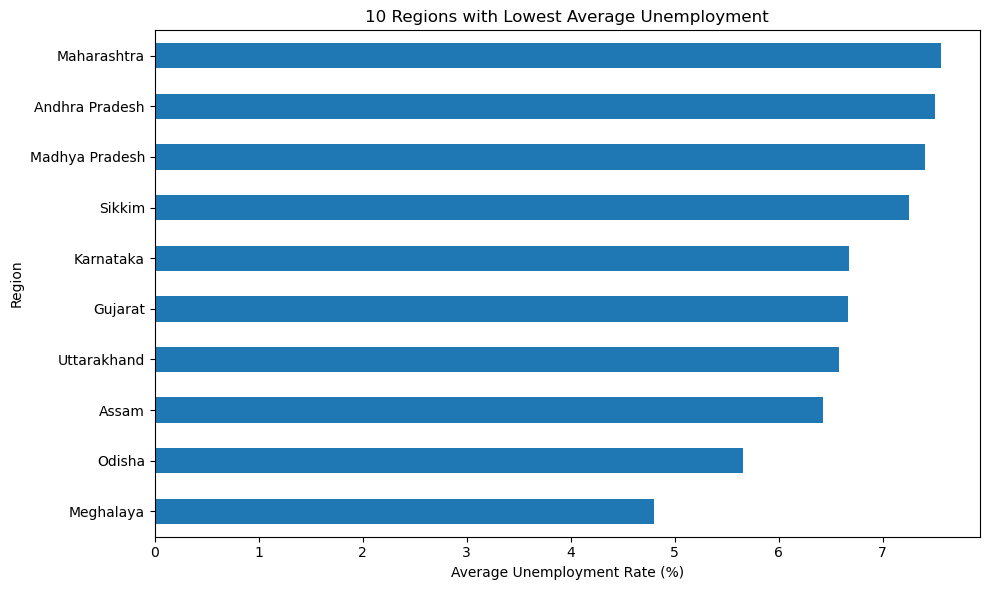

In [23]:
if region_column is not None and unemployment_column is not None:

    bottom_10 = region_unemployment.tail(10)

    plt.figure()

    bottom_10.sort_values().plot(
        kind="barh"
    )

    plt.title("10 Regions with Lowest Average Unemployment")
    plt.xlabel("Average Unemployment Rate (%)")
    plt.ylabel("Region")

    plt.tight_layout()

    plt.show()

# 19. FIND EMPLOYMENT COLUMN

In [24]:
employment_column = None

possible_employment_columns = [
    "Estimated Employed",
    "Estimated Employed ",
    "Employed",
    "employed"
]

for col in possible_employment_columns:

    if col in df.columns:
        employment_column = col
        break

print("\n================ EMPLOYMENT COLUMN ================\n")
print(employment_column)



================ EMPLOYMENT COLUMN ================

Estimated Employed


In [25]:
if employment_column is not None:

    print("\n================ EMPLOYMENT STATISTICS ================\n")

    print(
        "Average employed:",
        df[employment_column].mean()
    )

    print(
        "Minimum employed:",
        df[employment_column].min()
    )

    print(
        "Maximum employed:",
        df[employment_column].max()
    )


================ EMPLOYMENT STATISTICS ================

Average employed: 7201139.807692308
Minimum employed: 49420.0
Maximum employed: 45777509.0


# 21. EMPLOYMENT DISTRIBUTION

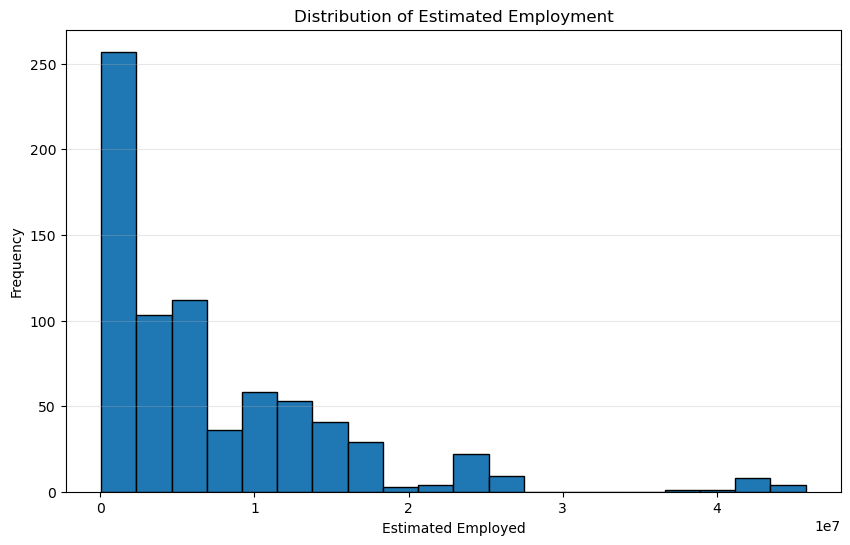

In [26]:

if employment_column is not None:

    plt.figure()

    plt.hist(
        df[employment_column],
        bins=20,
        edgecolor="black"
    )

    plt.title("Distribution of Estimated Employment")
    plt.xlabel("Estimated Employed")
    plt.ylabel("Frequency")

    plt.grid(axis="y", alpha=0.3)

    plt.show()


# 22. FIND LABOUR PARTICIPATION COLUMN

In [27]:
labour_column = None

possible_labour_columns = [
    "Estimated Labour Participation Rate (%)",
    "Estimated Labour Participation Rate",
    "Labour Participation Rate",
    "Labour Participation Rate (%)"
]

for col in possible_labour_columns:

    if col in df.columns:
        labour_column = col
        break

print("\n================ LABOUR PARTICIPATION COLUMN ================\n")
print(labour_column)



================ LABOUR PARTICIPATION COLUMN ================

Estimated Labour Participation Rate (%)


# 23. LABOUR PARTICIPATION STATISTICS

In [28]:

if labour_column is not None:

    print("\n================ LABOUR PARTICIPATION STATISTICS ================\n")

    print(
        "Average labour participation rate:",
        df[labour_column].mean()
    )

    print(
        "Minimum labour participation rate:",
        df[labour_column].min()
    )

    print(
        "Maximum labour participation rate:",
        df[labour_column].max()
    )



================ LABOUR PARTICIPATION STATISTICS ================

Average labour participation rate: 42.628137651821866
Minimum labour participation rate: 13.33
Maximum labour participation rate: 72.57


# 24. LABOUR PARTICIPATION DISTRIBUTION

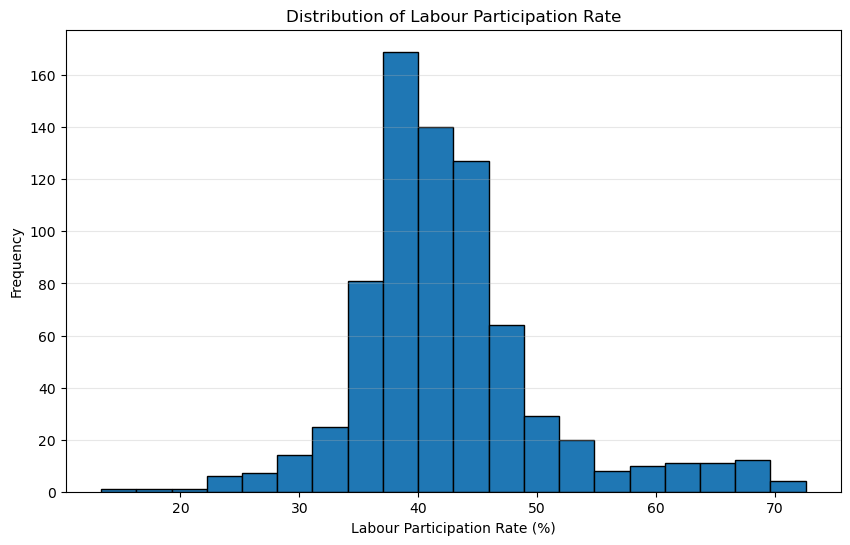

In [29]:
if labour_column is not None:

    plt.figure()

    plt.hist(
        df[labour_column],
        bins=20,
        edgecolor="black"
    )

    plt.title("Distribution of Labour Participation Rate")
    plt.xlabel("Labour Participation Rate (%)")
    plt.ylabel("Frequency")

    plt.grid(axis="y", alpha=0.3)

    plt.show()


# 25. CORRELATION ANALYSIS

In [30]:
numeric_df = df.select_dtypes(include=np.number)

print("\n================ CORRELATION MATRIX ================\n")
print(numeric_df.corr())



================ CORRELATION MATRIX ================

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.222715   
Estimated Labour Participation Rate (%)                         0.002636   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.222715   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)            0.011374   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                         0.002636  
Estimated Employed                                                      0.011374  
Estimated Labour Participation Rate (%)                                 1.000000  


# 26. CORRELATION HEATMAP WITHOUT SEABORN

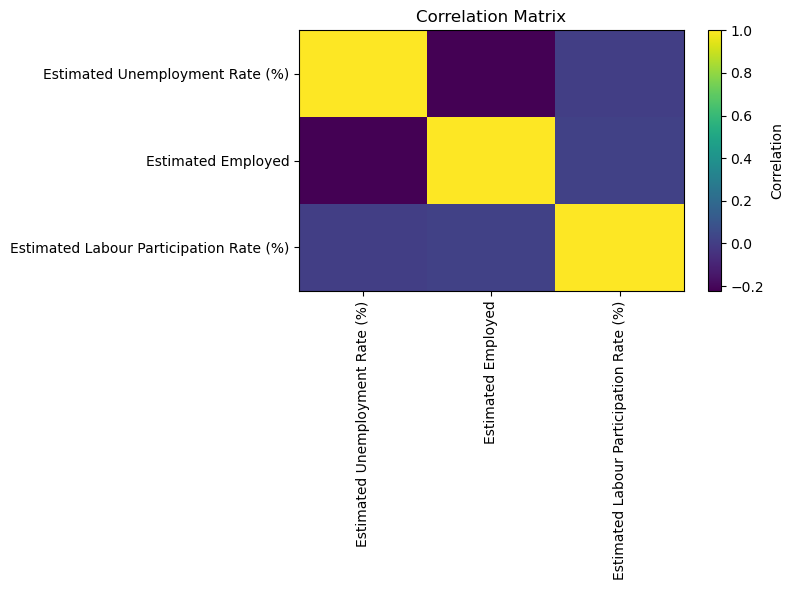

In [32]:
if len(numeric_df.columns) > 1:

    correlation_matrix = numeric_df.corr()

    plt.figure(
        figsize=(
            max(8, len(correlation_matrix.columns)),
            max(6, len(correlation_matrix.columns) * 0.7)
        )
    )

    plt.imshow(
        correlation_matrix,
        interpolation="nearest",
        aspect="auto"
    )

    plt.colorbar(label="Correlation")

    plt.xticks(
        range(len(correlation_matrix.columns)),
        correlation_matrix.columns,
        rotation=90
    )

    plt.yticks(
        range(len(correlation_matrix.columns)),
        correlation_matrix.columns
    )

    plt.title("Correlation Matrix")

    plt.tight_layout()

    plt.show()


# 27. UNEMPLOYMENT VS LABOUR PARTICIPATION

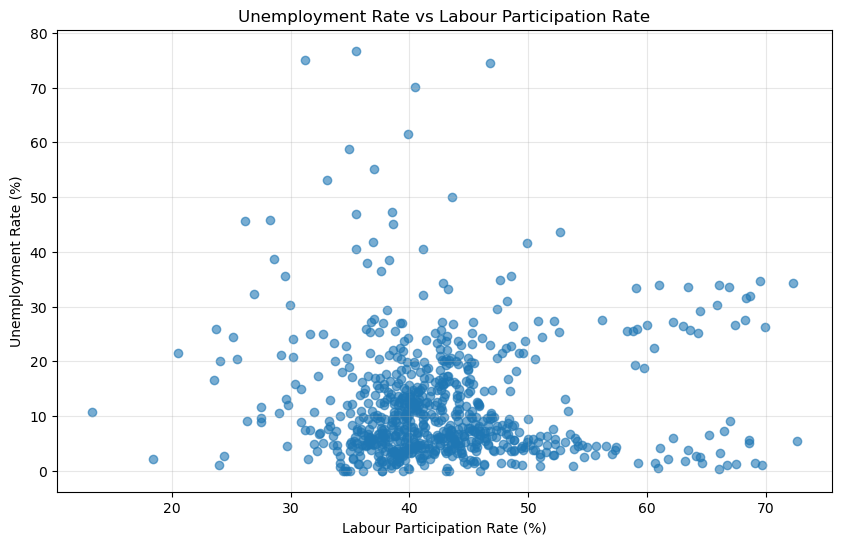

In [33]:
if (
    unemployment_column is not None
    and labour_column is not None
):

    plt.figure()

    plt.scatter(
        df[labour_column],
        df[unemployment_column],
        alpha=0.6
    )

    plt.title(
        "Unemployment Rate vs Labour Participation Rate"
    )

    plt.xlabel(
        "Labour Participation Rate (%)"
    )

    plt.ylabel(
        "Unemployment Rate (%)"
    )

    plt.grid(alpha=0.3)

    plt.show()


# 28. UNEMPLOYMENT VS EMPLOYMENT

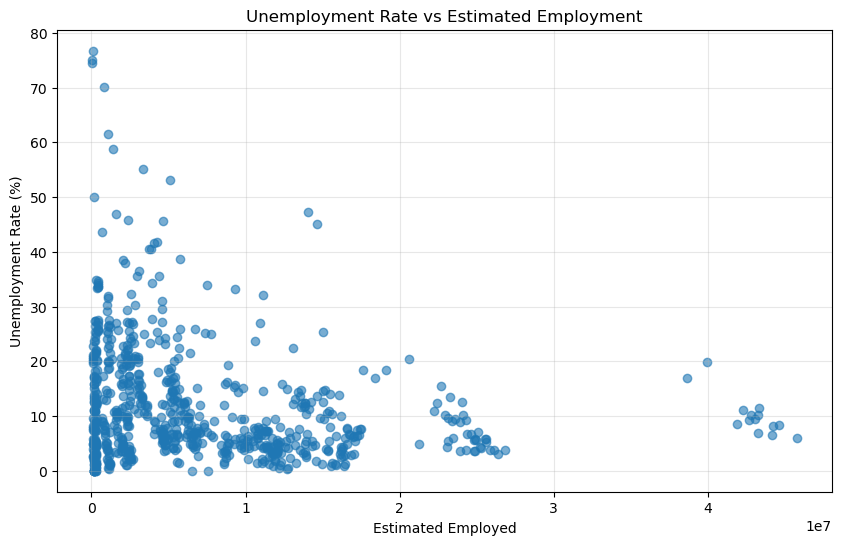

In [34]:

if (
    unemployment_column is not None
    and employment_column is not None
):

    plt.figure()

    plt.scatter(
        df[employment_column],
        df[unemployment_column],
        alpha=0.6
    )

    plt.title(
        "Unemployment Rate vs Estimated Employment"
    )

    plt.xlabel(
        "Estimated Employed"
    )

    plt.ylabel(
        "Unemployment Rate (%)"
    )

    plt.grid(alpha=0.3)

    plt.show()

# 29. TIME-SERIES ANALYSIS


================ UNEMPLOYMENT OVER TIME ================

Date
2019-05-31     8.874259
2019-06-30     9.303333
2019-07-31     9.033889
2019-08-31     9.637925
2019-09-30     9.051731
2019-10-31     9.900909
2019-11-30     9.841250
2019-12-31     9.497358
2020-01-31     9.950755
2020-02-29     9.964717
2020-03-31    10.700577
2020-04-30    23.641569
2020-05-31    24.875294
2020-06-30    11.903600
Name: Estimated Unemployment Rate (%), dtype: float64


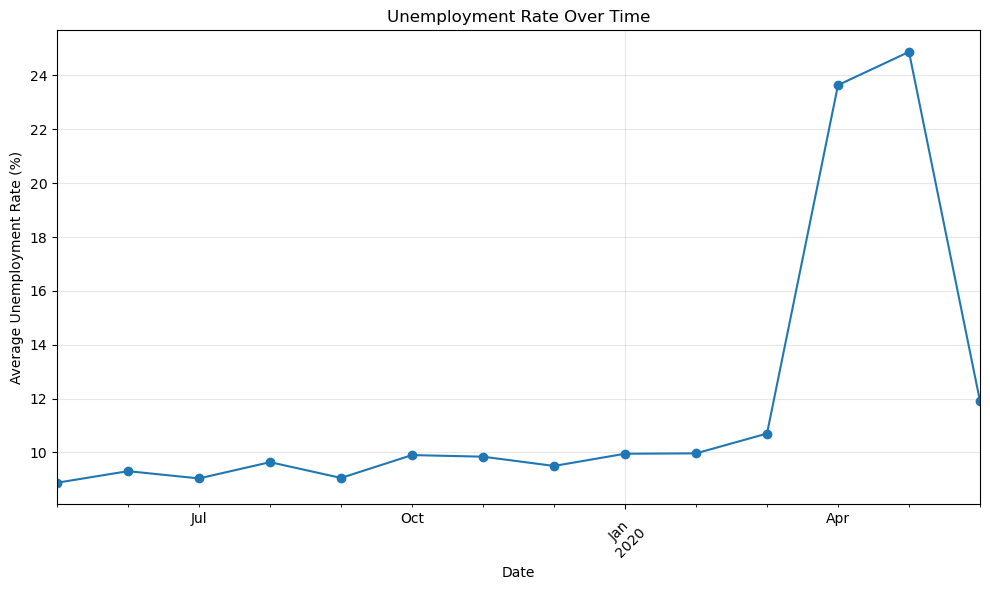

In [35]:
if (
    date_column is not None
    and unemployment_column is not None
):

    time_data = (
        df.dropna(
            subset=[date_column, unemployment_column]
        )
        .sort_values(date_column)
    )

    monthly_unemployment = (
        time_data
        .groupby(date_column)[unemployment_column]
        .mean()
    )

    print("\n================ UNEMPLOYMENT OVER TIME ================\n")
    print(monthly_unemployment)


    plt.figure()

    monthly_unemployment.plot(
        marker="o"
    )

    plt.title("Unemployment Rate Over Time")
    plt.xlabel("Date")
    plt.ylabel("Average Unemployment Rate (%)")

    plt.xticks(rotation=45)

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

# 30. REGION-WISE TIME SERIES

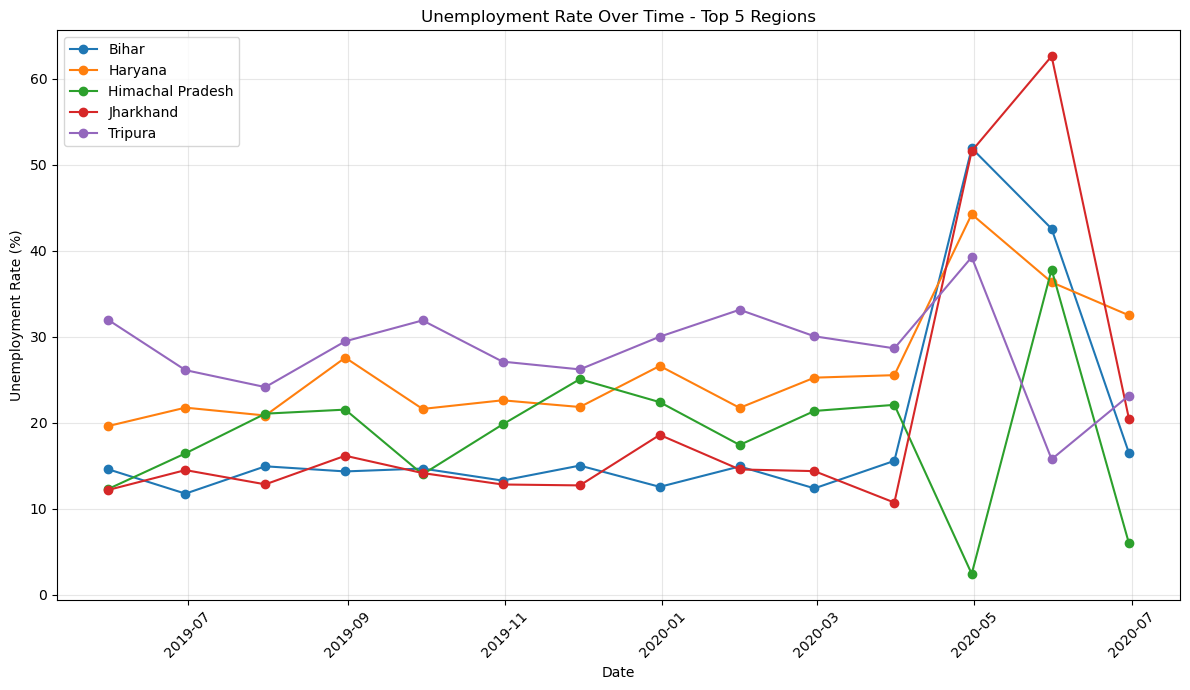

In [36]:
if (
    date_column is not None
    and region_column is not None
    and unemployment_column is not None
):

    # Select top 5 regions by average unemployment
    top_regions = (
        df.groupby(region_column)[unemployment_column]
        .mean()
        .sort_values(ascending=False)
        .head(5)
        .index
    )

    filtered_df = df[
        df[region_column].isin(top_regions)
    ]

    pivot_data = filtered_df.pivot_table(
        index=date_column,
        columns=region_column,
        values=unemployment_column,
        aggfunc="mean"
    )

    plt.figure(figsize=(12, 7))

    for region in pivot_data.columns:
        plt.plot(
            pivot_data.index,
            pivot_data[region],
            marker="o",
            label=region
        )

    plt.title(
        "Unemployment Rate Over Time - Top 5 Regions"
    )

    plt.xlabel("Date")
    plt.ylabel("Unemployment Rate (%)")

    plt.legend()

    plt.xticks(rotation=45)

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

# 31. HIGHEST UNEMPLOYMENT RECORDS

In [37]:
if unemployment_column is not None:

    print(
        "\n================ TOP 10 HIGHEST UNEMPLOYMENT RECORDS ================\n"
    )

    highest_unemployment = df.sort_values(
        by=unemployment_column,
        ascending=False
    ).head(10)

    print(highest_unemployment)



================ TOP 10 HIGHEST UNEMPLOYMENT RECORDS ================

               Region       Date Frequency  Estimated Unemployment Rate (%)  \
627        Puducherry 2020-04-30   Monthly                            76.74   
628        Puducherry 2020-05-31   Monthly                            75.00   
242        Puducherry 2020-04-30   Monthly                            74.51   
531         Jharkhand 2020-05-31   Monthly                            70.17   
530         Jharkhand 2020-04-30   Monthly                            61.48   
412             Bihar 2020-04-30   Monthly                            58.77   
145         Jharkhand 2020-05-31   Monthly                            55.10   
287        Tamil Nadu 2020-04-30   Monthly                            53.19   
507  Himachal Pradesh 2020-05-31   Monthly                            50.00   
38              Bihar 2020-05-31   Monthly                            47.26   

     Estimated Employed  Estimated Labour Participation Ra

# 32. LOWEST UNEMPLOYMENT RECORDS

In [38]:
if unemployment_column is not None:

    print(
        "\n================ TOP 10 LOWEST UNEMPLOYMENT RECORDS ================\n"
    )

    lowest_unemployment = df.sort_values(
        by=unemployment_column,
        ascending=True
    ).head(10)

    print(lowest_unemployment)


================ TOP 10 LOWEST UNEMPLOYMENT RECORDS ================

           Region       Date Frequency  Estimated Unemployment Rate (%)  \
618    Puducherry 2019-07-31   Monthly                              0.0   
617    Puducherry 2019-06-30   Monthly                              0.0   
77            Goa 2020-02-29   Monthly                              0.0   
51   Chhattisgarh 2020-04-30   Monthly                              0.0   
231    Puducherry 2019-05-31   Monthly                              0.0   
232    Puducherry 2019-06-30   Monthly                              0.0   
233    Puducherry 2019-07-31   Monthly                              0.0   
235    Puducherry 2019-09-30   Monthly                              0.0   
237    Puducherry 2019-11-30   Monthly                              0.0   
274        Sikkim 2020-04-30   Monthly                              0.0   

     Estimated Employed  Estimated Labour Participation Rate (%)   Area  
618            281117.0      

# 33. OUTLIER DETECTION USING IQR

In [39]:

if unemployment_column is not None:

    Q1 = df[unemployment_column].quantile(0.25)
    Q3 = df[unemployment_column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[unemployment_column] < lower_limit)
        |
        (df[unemployment_column] > upper_limit)
    ]

    print("\n================ OUTLIER ANALYSIS ================\n")

    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower limit:", lower_limit)
    print("Upper limit:", upper_limit)

    print(
        "Number of unemployment-rate outliers:",
        len(outliers)
    )

    print("\nOutlier records:")
    print(outliers)


================ OUTLIER ANALYSIS ================

Q1: 4.66
Q3: 15.88
IQR: 11.22
Lower limit: -12.170000000000002
Upper limit: 32.71
Number of unemployment-rate outliers: 35

Outlier records:
               Region       Date Frequency  Estimated Unemployment Rate (%)  \
37              Bihar 2020-04-30   Monthly                            45.09   
38              Bihar 2020-05-31   Monthly                            47.26   
105           Haryana 2020-04-30   Monthly                            41.61   
106           Haryana 2020-05-31   Monthly                            34.22   
107           Haryana 2020-06-30   Monthly                            35.57   
144         Jharkhand 2020-04-30   Monthly                            41.72   
145         Jharkhand 2020-05-31   Monthly                            55.10   
158         Karnataka 2020-04-30   Monthly                            33.17   
242        Puducherry 2020-04-30   Monthly                            74.51   
255            P

# 34. SAVE CLEANED DATASET

In [40]:
cleaned_file = "cleaned_unemployment_data.csv"

df.to_csv(
    cleaned_file,
    index=False
)

print(
    "\nCleaned dataset saved as:",
    cleaned_file
)



Cleaned dataset saved as: cleaned_unemployment_data.csv


# 35.covid-19 Impact Analysis 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Unemployment in India.csv")

In [8]:
df.columns = df.columns.str.strip()

In [14]:
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area',
       'year'],
      dtype='object')


In [16]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['year'] = df['Date'].dt.year

In [18]:
pre_covid = df[df['year']< 2020]['Estimated Unemployment Rate (%)'].mean()
during_covid = df[df['year'] >=2020]['Estimated Unemployment Rate (%)'].mean()   
print(f"Average Unemployment Pre-Covid (2019): {round(pre_covid,2)}%")
print(f"Average Unemployment During-Covid (2020+): {round(during_covid,2)}%")
print(f"Impact: Unemployment increased by {round(during_covid - pre_covid,2)}%")

Average Unemployment Pre-Covid (2019): 9.4%
Average Unemployment During-Covid (2020+): 15.1%
Impact: Unemployment increased by 5.7%


# Visualization or Seasonal Trends

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns


# Monthly Trend

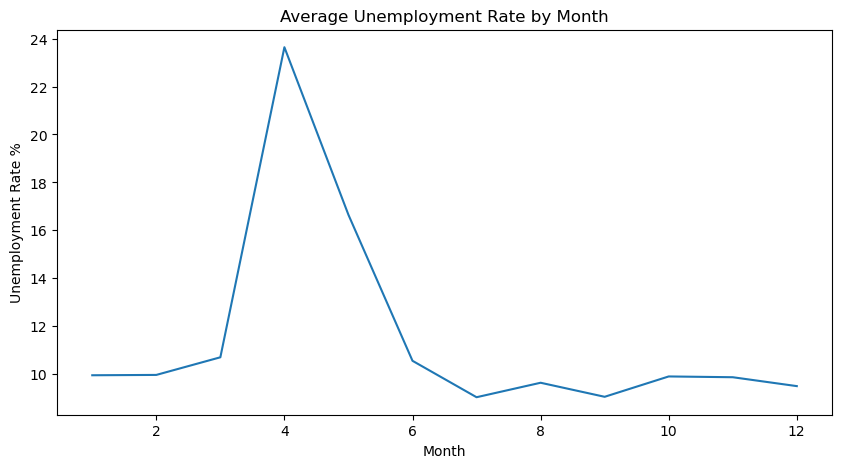

In [21]:
df['Month'] = df['Date'].dt.month
monthly_trend = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()
plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values)
plt.title('Average Unemployment Rate by Month')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate %')
plt.show()

In [42]:
print("\n============================================================")
print("                    DS SUMMARY")
print("============================================================")

print("\nDataset shape:", df.shape)

print(
    "\nNumber of numerical columns:",
    len(df.select_dtypes(include=np.number).columns)
)

print(
    "Number of categorical columns:",
    len(df.select_dtypes(include="object").columns)
)

print(
    "Number of missing values:",
    df.isnull().sum().sum()
)

print(
    "Number of duplicate rows:",
    df.duplicated().sum()
)

if unemployment_column is not None:

    print(
        "\nAverage unemployment rate:",
        round(
            df[unemployment_column].mean(),
            2
        ),
        "%"
    )

    print(
        "Highest unemployment rate:",
        round(
            df[unemployment_column].max(),
            2
        ),
        "%"
    )

    print(
        "Lowest unemployment rate:",
        round(
            df[unemployment_column].min(),
            2
        ),
        "%"
    )

print("\n============================================================")
print("DS PROJECT COMPLETED SUCCESSFULLY")
print("============================================================")


                    DS SUMMARY

Dataset shape: (741, 7)

Number of numerical columns: 3
Number of categorical columns: 3
Number of missing values: 0
Number of duplicate rows: 0

Average unemployment rate: 11.78 %
Highest unemployment rate: 76.74 %
Lowest unemployment rate: 0.0 %

DS PROJECT COMPLETED SUCCESSFULLY


# Conclusion

The unemployment analysis project using Python provided valuable insights into unemployment trends and patterns across different periods and regions. By using data analysis and visualization techniques, the project helped identify changes in unemployment rates and understand factors that may influence employment conditions.

Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn made it possible to clean, analyze, and visualize the data effectively. The analysis demonstrates how data science can transform raw unemployment data into meaningful information that supports better understanding and decision-making.

Overall, this project highlights the importance of data-driven analysis in studying unemployment and can serve as a foundation for further research, including predictive modeling and forecasting future unemployment trends.
